In [2]:
import kagglehub
import os
import shutil

# 1. Download the latest version to a temporary path
path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'microsoft-catsvsdogs-dataset' dataset.
Path to dataset files: /kaggle/input/microsoft-catsvsdogs-dataset


In [3]:
# 2. Define the destination
train_dir = '/content/train'

# 3. Move the 'PetImages' folder to our working directory
# We use copytree to move all Cat and Dog images at once
source_path = os.path.join(path, 'PetImages')

if os.path.exists(train_dir):
    shutil.rmtree(train_dir) # Clear old attempts

shutil.copytree(source_path, train_dir)

# 4. Remove the broken/non-image files (Crucial Step!)
for folder in ['Cat', 'Dog']:
    for file in os.listdir(os.path.join(train_dir, folder)):
        if not file.endswith('.jpg'):
            os.remove(os.path.join(train_dir, folder, file))

print(f"✅ SUCCESS: Data is cleaned and ready in {train_dir}")

✅ SUCCESS: Data is cleaned and ready in /content/train


In [24]:
import os
import tensorflow as tf

data_dir = '/content/train'
num_skipped = 0

print("🚀 Starting Nuclear Cleanup... checking every image with TensorFlow's decoder.")

for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join(data_dir, folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            # Check if the file starts with the JPEG magic number
            is_jfif = tf.compat.as_bytes("JFIF") in fobj.peek(10)
        finally:
            fobj.close()

        if not is_jfif:
            num_skipped += 1
            # Delete non-JFIF files
            os.remove(fpath)
        else:
            try:
                # Try to decode it exactly how the model will
                img = tf.io.read_file(fpath)
                img = tf.image.decode_jpeg(img, channels=3)
            except:
                num_skipped += 1
                os.remove(fpath)

print(f"✅ CLEANUP COMPLETE! Deleted {num_skipped} invisible 'poison' files.")

🚀 Starting Nuclear Cleanup... checking every image with TensorFlow's decoder.
✅ CLEANUP COMPLETE! Deleted 1588 invisible 'poison' files.


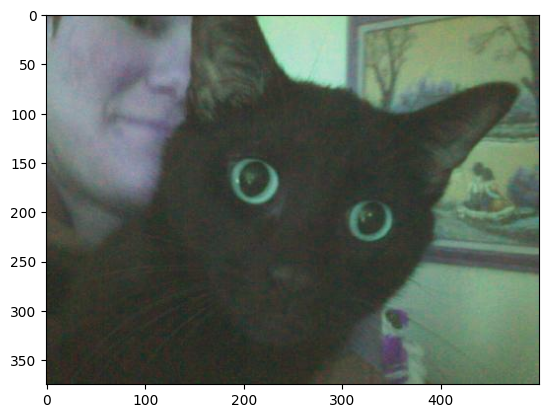

In [50]:
import cv2

test_img = cv2.imread('/content/train/Cat/10226.jpg')

plt.imshow(test_img)

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten

In [25]:
data_dir = '/content/train'

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(256, 256),
    batch_size=32
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(256, 256),
    batch_size=32
)

Found 23410 files belonging to 2 classes.
Using 18728 files for training.
Found 23410 files belonging to 2 classes.
Using 4682 files for validation.


In [26]:
def process(image, label):
    image = tf.cast(image/255.0, tf.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [27]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [28]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [30]:
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.5867 - loss: 0.6685 - val_accuracy: 0.6707 - val_loss: 0.5921
Epoch 2/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 44s 74ms/step - accuracy: 0.7360 - loss: 0.5254 - val_accuracy: 0.7589 - val_loss: 0.4908
Epoch 3/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 46s 78ms/step - accuracy: 0.8046 - loss: 0.4118 - val_accuracy: 0.7644 - val_loss: 0.5021
Epoch 4/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 81s 76ms/step - accuracy: 0.8769 - loss: 0.2838 - val_accuracy: 0.7379 - val_loss: 0.6728
Epoch 5/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 85s 82ms/step - accuracy: 0.9377 - loss: 0.1568 - val_accuracy: 0.7367 - val_loss: 0.8973
Epoch 6/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 78s 76ms/step - accuracy: 0.9690 - loss: 0.0875 - val_accuracy: 0.7591 - val_loss: 1.0673
Epoch 7/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 43s 74ms/step - accuracy: 0.9808 - loss: 0.0571 - val_accuracy: 0.7537 - val_loss: 1.2158
Epoch 8/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 87s 82ms/step - accuracy: 0.9845 - loss: 0.0480 - 

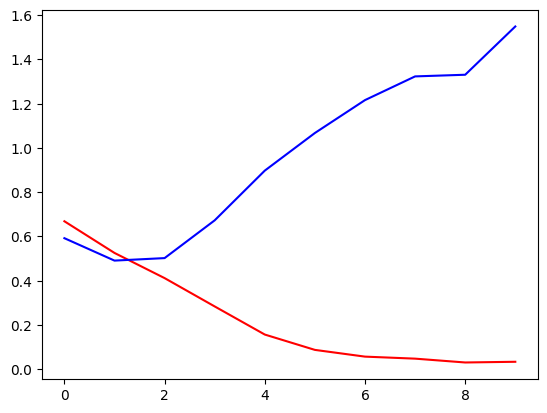

In [32]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='test')

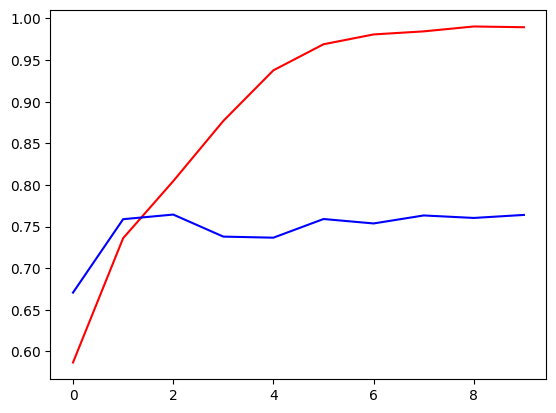

In [33]:
plt.plot(history.history['accuracy'], color = 'red', label = 'train')
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'test')

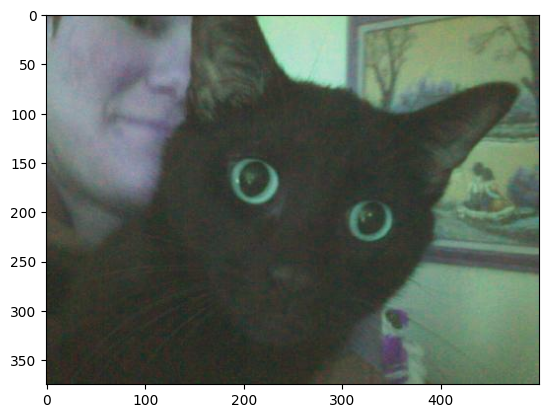

In [51]:
test_img = cv2.imread('/content/train/Cat/10226.jpg')

plt.imshow(test_img)

In [52]:
test_img.shape

(375, 500, 3)

In [53]:
test_img = cv2.resize(test_img, (256,256))
test_input = test_img.reshape((1,256,256,3))
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.]], dtype=float32)